# Drive Cycle Simulation

This notebook demonstrates the `run_drive_cycle` function for comprehensive drive cycle analysis.

## Features
- Time series simulation (voltage, current, power, temperature)
- Energy analysis (discharge, regeneration, net consumption)
- Range estimation (distance, drive/flight time)

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from model_library import run_spmet_drivecycle

## 1. Load Drive Cycle

Drive cycle: Aero Quad Drone
Duration: 599 s (10.0 min)
Power range: -84.123 to -24.257 W


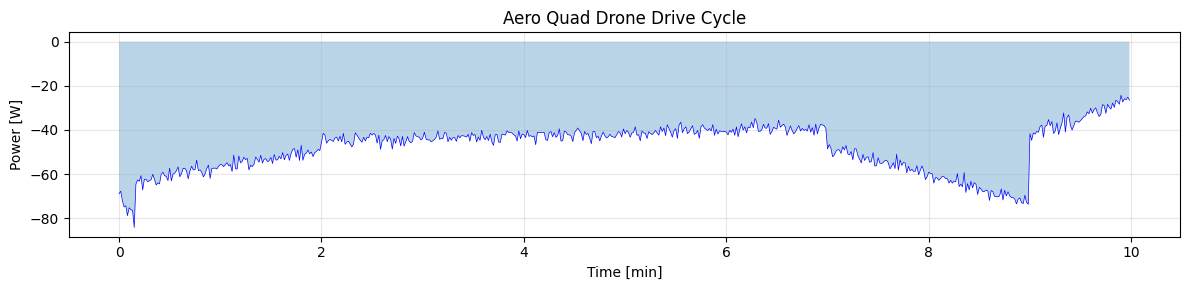

In [2]:
# Available drive cycles:
# - Auto WLTP, Auto US06, Track Nurburgring
# - Aero Quad Drone, Aero UAV, Aero eVTOL

drive_cycle_name = "Aero Quad Drone"
drive_cycle_path = Path(f"../drive_cycles/{drive_cycle_name} Power.csv")
drive_cycle_df = pd.read_csv(drive_cycle_path)

print(f"Drive cycle: {drive_cycle_name}")
print(f"Duration: {drive_cycle_df['time (s)'].max():.0f} s ({drive_cycle_df['time (s)'].max()/60:.1f} min)")
print(f"Power range: {drive_cycle_df['power (W)'].min():.3f} to {drive_cycle_df['power (W)'].max():.3f} W")

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(drive_cycle_df['time (s)']/60, drive_cycle_df['power (W)'], 'b-', linewidth=0.5)
ax.fill_between(drive_cycle_df['time (s)']/60, drive_cycle_df['power (W)'], 0, alpha=0.3)
ax.set_xlabel('Time [min]')
ax.set_ylabel('Power [W]')
ax.set_title(f'{drive_cycle_name} Drive Cycle')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Load Cell Design

In [3]:
manifest_path = Path("../cells/Tesla_Model3_Prismatic_160Ah_manifest.json")
material_path = Path("../materials")

with open(manifest_path, 'r') as f:
    cell_design_manifest = json.load(f)
    
    for component in ["separator", "electrolyte"]:
        material_name = cell_design_manifest["cell_design"][component]["material"]["type"]
        with open(material_path / f"{material_name}.json", "r") as mf:
            cell_design_manifest["cell_design"][component]["material"] = json.load(mf)

    for component in ["negative_electrode", "positive_electrode"]:
        material_name = cell_design_manifest["cell_design"][component]["coating"]["formulation"]["primary_active_material"]["name"]
        with open(material_path / f"{material_name}.json", "r") as mf:
            cell_design_manifest["cell_design"][component]["material"] = json.load(mf)

cell_design = cell_design_manifest["cell_design"]
cell_design["nominal_capacity"] = {"value": cell_design_manifest['kpis']['nominal_capacity']['value'], "unit": "Ah"}
cell_design["nominal_energy"] = {"value": cell_design_manifest['kpis']['nominal_energy']['value'], "unit": "Wh"}
cell_design["cell_volume"] = {"value": cell_design_manifest['kpis']['cell_volume']['value'], "unit": "cm3"}

print(f"Cell: {manifest_path.stem}")
print(f"Capacity: {cell_design['nominal_capacity']['value']:.1f} Ah")
print(f"Energy: {cell_design['nominal_energy']['value']:.1f} Wh")

Cell: Tesla_Model3_Prismatic_160Ah_manifest
Capacity: 161.1 Ah
Energy: 515.5 Wh


## 3. Run Simulation

In [ ]:
# Prepare config
config = {
    "ambient_temperature_K": 298.15,
    "initial_temperature_K": 298.15,
    "initial_soc": 0.80,
    "upper_voltage_cutoff_V": cell_design["upper_voltage_cutoff"]["value"],
    "lower_voltage_cutoff_V": cell_design["lower_voltage_cutoff"]["value"],
    "contact_resistance_Ohm": 0.0001,
    "total_heat_transfer_coefficient_W_m2K": 10,
    "cooling_surface_area_m2": 0.01,
    "period": "1 second",
    "min_soc": 0.10,
    "max_soc": 0.90,
    "drive_cycle": {
        "time_s": drive_cycle_df['time (s)'].values,
        "power_W": -drive_cycle_df['power (W)'].values,
        "label": drive_cycle_name,
    },
}

# Run
result = run_spmet_drivecycle(cell_design=cell_design, simulation_config=config)

NameError: name 'run_spmet_drive_cycle' is not defined

## 4. Results Report

In [ ]:
print_drive_cycle_report(result)

In [ ]:
# Access result dict directly
if result['success']:
    print("Result keys:", list(result.keys()))
    print("\nTimeseries arrays:", list(result['timeseries'].keys()))
    print("\nRange analysis:", result['range_analysis'])

## 5. Visualizations

In [ ]:
if result['success']:
    ts = result['timeseries']
    
    fig, axes = plt.subplots(5, 1, figsize=(14, 10), sharex=True)

    axes[0].plot(ts['time_s']/60, ts['current_A'], 'b-', lw=0.5)
    axes[0].fill_between(ts['time_s']/60, ts['current_A'], 0, alpha=0.3)
    axes[0].set_ylabel('Current [A]')
    axes[0].set_title(f'{drive_cycle_name} Simulation')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(ts['time_s']/60, ts['voltage_V'], 'g-', lw=1)
    axes[1].set_ylabel('Voltage [V]')
    axes[1].grid(True, alpha=0.3)

    axes[2].plot(ts['time_s']/60, ts['power_W']/1000, 'orange', lw=0.5)
    axes[2].fill_between(ts['time_s']/60, ts['power_W']/1000, 0, alpha=0.3, color='orange')
    axes[2].set_ylabel('Power [kW]')
    axes[2].grid(True, alpha=0.3)

    axes[3].plot(ts['time_s']/60, ts['soc'] * 100, 'k-', lw=1)
    axes[3].set_xlabel('Time [min]')
    axes[3].set_ylabel('State of charge [%]')
    axes[3].grid(True, alpha=0.3)


    axes[4].plot(ts['time_s']/60, ts['temperature_K'] - 273.15, 'r-', lw=1)
    axes[4].set_xlabel('Time [min]')
    axes[4].set_ylabel('Temperature [°C]')
    axes[4].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [ ]:
if result['success']:
    ra = result['range_analysis']
    nominal_capacity = cell_design['nominal_capacity']['value']
    
    # Range at different SOC levels
    soc_levels = np.arange(0.2, 1.01, 0.1)
    ranges_km = []
    times_min = []
    
    for soc in soc_levels:
        avail_cap = nominal_capacity * (soc - ra['min_soc'])
        if avail_cap > 0 and ra['capacity_per_cycle_Ah'] > 0:
            n_cycles = avail_cap / ra['capacity_per_cycle_Ah']
            ranges_km.append(n_cycles * ra.get('cycle_distance_km', 0))
            times_min.append(n_cycles * ra['cycle_duration_s'] / 60)
        else:
            ranges_km.append(0)
            times_min.append(0)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    if ra.get('cycle_distance_km'):
        axes[0].bar(soc_levels * 100, ranges_km, width=8, color='steelblue', alpha=0.8)
        axes[0].set_xlabel('Starting SOC [%]')
        axes[0].set_ylabel('Range [km]')
        axes[0].set_title('Range vs SOC')
        axes[0].grid(True, alpha=0.3, axis='y')
        axes[0].axvline(x=ra['initial_soc']*100, color='red', linestyle='--', label='Simulated')
        axes[0].legend()
    
    axes[1].bar(soc_levels * 100, times_min, width=8, color='darkorange', alpha=0.8)
    axes[1].set_xlabel('Starting SOC [%]')
    axes[1].set_ylabel('Time [min]')
    time_label = 'Flight' if ra['is_aerial'] else 'Drive'
    axes[1].set_title(f'{time_label} Time vs SOC')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].axvline(x=ra['initial_soc']*100, color='red', linestyle='--', label='Simulated')
    axes[1].legend()
    
    plt.suptitle(f'Range Analysis: {ra["cycle_label"]}', fontweight='bold')
    plt.tight_layout()
    plt.show()

## 6. Example with Pack Config and Vehicle Physics

Estimate drone range from power profile using vehicle weight and aerodynamics.

In [ ]:
# Load drone power profile

print(f"Drone power profile")
print(f"Duration: {drive_cycle_df['time (s)'].max():.0f} s")
print(f"Power range: {drive_cycle_df['power (W)'].min():.1f} to {drive_cycle_df['power (W)'].max():.1f} W")

# Plot
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(drive_cycle_df['time (s)']/60, drive_cycle_df['power (W)'], 'b-', linewidth=1)
ax.set_xlabel('Time [min]')
ax.set_ylabel('Power [W]')
ax.set_title('Quad Drone Power Profile (Pack Level)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Configure with pack and vehicle parameters
simulation_config = {
    "ambient_temperature_K": 298.15,
    "initial_temperature_K": 298.15,
    "initial_soc": 1.0,  # Start fully charged
    "upper_voltage_cutoff_V": cell_design["upper_voltage_cutoff"]["value"],
    "lower_voltage_cutoff_V": cell_design["lower_voltage_cutoff"]["value"],
    "contact_resistance_Ohm": 0.0001,
    "total_heat_transfer_coefficient_W_m2K": 25,  # Better cooling for drone
    "cooling_surface_area_m2": 0.02,
    "period": "1 second",
    "min_soc": 0.20,  # Reserve 20% for safety
    "max_soc": 1.0,
    "pack_nominal_voltage_V": 22.2,  # 6S Li-ion pack
    "pack_power_W": 888.0,  # Max pack power
    "pack_energy_Wh": 900.0,  # Approximate pack energy
    
    # Vehicle parameters for range estimation from power
   "vehicle_weight_kg": 5.0,              # Drone weight with battery
   "vehicle_drag_coefficient": 1.0,        # Quadcopter has high drag
   "vehicle_frontal_area_m2": 0.04,       # ~20cm x 20cm
   "vehicle_rolling_resistance": 0.0,
   "vehicle_drivetrain_efficiency": 0.75,          # Motor + propeller efficiency    
    # Drive cycle with pack-level power (will be converted to cell power)
    "drive_cycle": {
        "time_s": drive_cycle_df['time (s)'].values,
        "power_W": -drive_cycle_df['power (W)'].values,  # Flip sign: positive = discharge
        "label": "Drive Cycle",
    },
}

# Run simulation
drone_result = run_drive_cycle(cell_design=cell_design, simulation_config=simulation_config)

In [ ]:
# Print full report including pack and vehicle physics
print_drive_cycle_report(drone_result)

In [ ]:
# Plot speed profile if estimated from power
if drone_result['success'] and 'speed_kmh' in drone_result['timeseries']:
    ts = drone_result['timeseries']
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    
    # Power
    axes[0].plot(ts['time_s']/60, ts['power_W'], 'b-', lw=1)
    axes[0].set_ylabel('Cell Power [W]')
    axes[0].set_title('Drone Simulation with Vehicle Physics')
    axes[0].grid(True, alpha=0.3)
    
    # Speed (estimated from power)
    axes[1].plot(ts['time_s']/60, ts['speed_kmh'], 'g-', lw=1)
    axes[1].set_ylabel('Estimated Speed [km/h]')
    axes[1].grid(True, alpha=0.3)
    
    # Temperature
    axes[2].plot(ts['time_s']/60, ts['temperature_K'] - 273.15, 'r-', lw=1)
    axes[2].set_xlabel('Time [min]')
    axes[2].set_ylabel('Temperature [°C]')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()